In [1]:
import random

import networkx as nx
import osmnx as ox
import pandas as pd
import geopandas as gpd
from pathlib import Path
import time
import matplotlib.pyplot as plt

from src.preprocessing.networks.create_travel_time_tables import create_travel_time_table
from src.preprocessing.networks.create_totally_routable_network import add_edges_to_make_nw_completely_routable_tt_matrix

import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
from shapely.ops import transform
from pyproj import Transformer
import numpy as np

# TODO: convert into a script

In [2]:
def rasterize_edges(gdf_edges, resolution=1, save_path=None):
    """Rasterizes an edges GeoDataFrame and saves it as a GeoTIFF in EPSG:3857."""

    # Ensure edges are in EPSG:3857
    if gdf_edges.crs is None or gdf_edges.crs.to_string() != "EPSG:3857":
        transformer = Transformer.from_crs(gdf_edges.crs, "EPSG:3857", always_xy=True)
        gdf_edges["geometry"] = gdf_edges["geometry"].apply(lambda geom: transform(transformer.transform, geom))
        gdf_edges.crs = "EPSG:3857"

    # Get bounding box in EPSG:3857
    minx, miny, maxx, maxy = gdf_edges.total_bounds
    minx -= 1000  # Add buffer in meters
    miny -= 1000
    maxx += 1000
    maxy += 1000

    # Compute raster dimensions
    width = max(int((maxx - minx) / resolution), 1)
    height = max(int((maxy - miny) / resolution), 1)

    # Create empty raster array (single band, dtype=uint8)
    raster = np.zeros((height, width), dtype=np.uint8)

    # Convert GeoDataFrame geometry to shapes
    shapes = ((geom, 1) for geom in gdf_edges.geometry.buffer(3))  # Small buffer in meters

    # Rasterize edges
    transform_obt = from_bounds(minx, miny, maxx, maxy, width, height)
    raster = rasterize(shapes, out_shape=(height, width), transform=transform_obt, fill=255, default_value=0,
                       all_touched=True)

    # Save to GeoTIFF with EPSG:3857
    with rasterio.open(
            f"{save_path}/drawn_map.tif", "w", driver="GTiff",
            height=height, width=width,
            count=1, dtype=raster.dtype,
            crs="EPSG:3857",  # Ensure CRS is EPSG:3857
            transform=transform_obt,
            nodata=0
    ) as dst:
        dst.write(raster, 1)

    print(f"Raster saved at {save_path}/drawn_map.tif with CRS EPSG:3857")

In [12]:
import matplotlib.pyplot as plt

def draw_city_map(G, N, show_labels=False, max_size=12):
    pos = {i: (i % N, (-i-1) // N) for i in G.nodes()}  # grid layout

    plt.figure(figsize=(max_size, max_size))

    # Draw intersections (tiny black dots)
    nx.draw_networkx_nodes(G, pos, node_size=5, node_color="black")

    drawn = set()
    for u, v in G.edges():
        if (v, u) in drawn:
            continue  # skip duplicate for two-way

        x1, y1 = pos[u]
        x2, y2 = pos[v]

        if G.has_edge(v, u):
            # Two-way: gray line
            plt.plot([x1, x2], [y1, y2], color="gray", linewidth=0.5)
            drawn.add((u, v))
            drawn.add((v, u))
        else:
            # One-way: red line with arrow in the middle
            plt.plot([x1, x2], [y1, y2], color="red", linewidth=0.7)

            # Arrow at midpoint
            xm, ym = (x1+x2)/2, (y1+y2)/2
            dx, dy = (x2-x1)*0.2, (y2-y1)*0.2  # short arrow
            plt.arrow(xm, ym, dx, dy,
                      head_width=0.2, head_length=0.2,
                      fc="red", ec="red", linewidth=0.5,
                      length_includes_head=True)

    if show_labels and N <= 15:  # avoid clutter for big grids
        nx.draw_networkx_labels(G, pos, font_size=6)

    plt.axis("off")
    plt.gca().set_aspect("equal")
    plt.show()

In [13]:
def create_grid_data(network_name, grid_size, spacing=100, avg_speed=60, dropout=0.9):
    start = time.time()
    # Create graph
    crs = "EPSG:32633"
    G = nx.MultiDiGraph(crs=crs)

    # Create nodes
    nodes = []
    node_id = 0
    for i in range(grid_size):
        for j in range(grid_size):
            x, y = i * spacing, j * spacing  # Local coordinate system
            G.add_node(node_id, x=x, y=y, source_edge_id=node_id)
            nodes.append((node_id, x, y))
            node_id += 1

    # Create edges (two-way streets)
    edges = []
    edge_id = 0
    for i in range(grid_size):
        for j in range(grid_size):
            node = i * grid_size + j

            # Right neighbor
            if j < grid_size - 1:
                right_node = node + 1
                if np.random.rand() < dropout:
                    G.add_edge(node, right_node, source_edge_id=edge_id, distance=spacing,
                               travel_time=spacing / (avg_speed / 3.6))
                    edges.append((node, right_node))
                    edge_id += 1
                if np.random.rand() < dropout:
                    G.add_edge(right_node, node, source_edge_id=edge_id, distance=spacing,
                               travel_time=spacing / (avg_speed / 3.6))
                    edges.append((right_node, node))
                    edge_id += 1

            # Top neighbor
            if i < grid_size - 1:
                top_node = node + grid_size
                if np.random.rand() < dropout:
                    G.add_edge(top_node, node, source_edge_id=edge_id, distance=spacing,
                               travel_time=spacing / (avg_speed / 3.6))
                    edges.append((top_node, node))
                    edge_id += 1
                if np.random.rand() < dropout:
                    G.add_edge(node, top_node, source_edge_id=edge_id, distance=spacing,
                               travel_time=spacing / (avg_speed / 3.6))
                    edges.append((node, top_node))
                    edge_id += 1

    #G = ox.projection.project_graph(G_source, to_crs=crs)
    #G = ox.routing.add_edge_speeds(G)
    #G = ox.routing.add_edge_travel_times(G)
    print(f"Grid graph loaded.")
    draw_city_map(G, grid_size)

    while not nx.is_strongly_connected(G):
        print(nx.condensation(G))
        sccs = list(nx.strongly_connected_components(G))
        random.shuffle(sccs)
        compmap = {}
        for k, scc in enumerate(sccs):
            for node in scc:
                compmap[node] = k
        connected_set = set()
        print(f"Found {len(sccs)} components")
        for k, scc in enumerate(sccs):
            print(f"Linking component {k}: {scc}")
            scc_list = list(scc)
            random.shuffle(scc_list)
            for i in scc_list:
                print(f"\tChecking node {i}...")
                connected = False
                cardinals = []
                if i >= grid_size:
                    cardinals.append(i - grid_size)
                if i < grid_size*(grid_size-1):
                    cardinals.append(i + grid_size)
                if i % grid_size != 0:
                    cardinals.append(i - 1)
                if i % grid_size != grid_size-1:
                    cardinals.append(i + 1)
                random.shuffle(cardinals)
                print(f"\tNode {i} has neighbors {[{card:compmap[card] for card in cardinals}]}")
                for neighbor in cardinals:
                    if {k, compmap[neighbor]} in connected_set:
                        print(f"\tComponents {k} and {compmap[neighbor]} have already been connected this pass, skipping...")
                        continue
                    if neighbor not in scc:
                        print(f"\tNeighbor {neighbor} not in scc, linking {k} to {compmap[neighbor]}:")
                        if (i, neighbor) not in edges:
                            G.add_edge(i, neighbor, source_edge_id=edge_id, distance=spacing,
                               travel_time=spacing / (avg_speed / 3.6))
                            edges.append((i, neighbor))
                            edge_id += 1
                            connected = True
                            print(f"\tAdded edge from {i} to {neighbor}")
                            connected_set.add(frozenset({k, compmap[neighbor]}))
                        if (neighbor, i) not in edges:
                            G.add_edge(neighbor, i, source_edge_id=edge_id, distance=spacing,
                               travel_time=spacing / (avg_speed / 3.6))
                            edges.append((neighbor, i))
                            edge_id += 1
                            connected = True
                            print(f"\tAdded edge from {neighbor} to {i}")
                            connected_set.add(frozenset({k, compmap[neighbor]}))
                    else:
                        print(f"\tNeighbor {neighbor} belongs to component {k} too, skipping")
                if connected:
                    print(f"Connected component {scc}. New total component count is {nx.number_strongly_connected_components(G)}")
                    break
        print(f"Connection pass done. Resulting graph has {nx.number_strongly_connected_components(G)} components")
    print("Graph fully connected.")
    draw_city_map(G, grid_size)

    # Node and edge GeoDataFrame
    nodes, edges = ox.graph_to_gdfs(G)

    print(f"Loaded {nodes.shape[0]} nodes and {edges.shape[0]} edges.")
    # Formatting for FleetPy - Nodes
    node_ids = nodes.index.values
    new_node_ids = list(range(len(node_ids)))
    id_mapping = dict(zip(list(list(node_ids)), new_node_ids))
    formatted_nodes = nodes.reset_index()
    formatted_nodes["node_index"] = formatted_nodes["source_edge_id"].map(id_mapping)
    formatted_nodes = formatted_nodes.rename(columns={"x": "pos_x", "y": "pos_y"})
    formatted_nodes["is_stop_only"] = False
    # Formatting for FleetPy - Edges
    formatted_edges = edges.rename(index=id_mapping).reset_index()
    formatted_edges = formatted_edges.rename(columns={"u": "from_node",
                                                      "v": "to_node",
                                                      })
    print(f"Data formatted for FleetPy use. Creating {network_name} subfolder in data/networks/...")

    # Creating network folder
    nw_path = Path("data") / Path("networks") / Path(network_name)
    base_path = nw_path / Path("base")
    base_path.mkdir(parents=True, exist_ok=True)
    # Save nodes and edges to CSV
    formatted_nodes[["node_index","is_stop_only","pos_x","pos_y"]].to_csv(base_path / Path('nodes.csv'), index=False)
    formatted_edges[["from_node","to_node","distance","travel_time","source_edge_id"]].to_csv(base_path / Path('edges.csv'), index=False)
    # Save nodes and edges to GeoJSON
    formatted_nodes[["node_index","is_stop_only","source_edge_id", "geometry"]].to_file(
        base_path / Path('nodes_all_infos.geojson'), driver='GeoJSON')
    formatted_edges[["from_node","to_node","distance","travel_time","source_edge_id", "geometry"]].to_file(
        base_path / Path('edges_all_infos.geojson'), driver='GeoJSON')
    with open(base_path / Path("crs.info"), "w") as crs_file:
        crs_file.write(crs)
    print(f"Initial data saved to {base_path}.")
    print(f"Running preprocessing and route completion steps...")

    # Use imported preprocessing functions to pre-calculate the travel-time table
    create_travel_time_table(nw_path)
    # Make network fully routable (requires travel-time table)
    add_edges_to_make_nw_completely_routable_tt_matrix(nw_path)
    # Run the travel-time table generator again since we added new edges
    create_travel_time_table(nw_path)

    vh_dist_path = Path("data") / Path("fleetctrl") / Path("initial_vehicle_distribution") / Path(network_name)

    vh_dist_path.mkdir(exist_ok=True)
    dist_data = {'node_index': [(grid_size // 2) * grid_size + grid_size // 2], 'probability': [1.0]}
    dist_df = pd.DataFrame(dist_data)
    dist_df.to_csv(vh_dist_path / Path('init_veh_dist.csv'), index=False)


    rasterize_edges(formatted_edges, save_path=nw_path, resolution=2)

    print(f"Done in {time.time() - start}s.")
    print(f"Network {network_name} saved locally at {nw_path}")

Grid graph loaded.


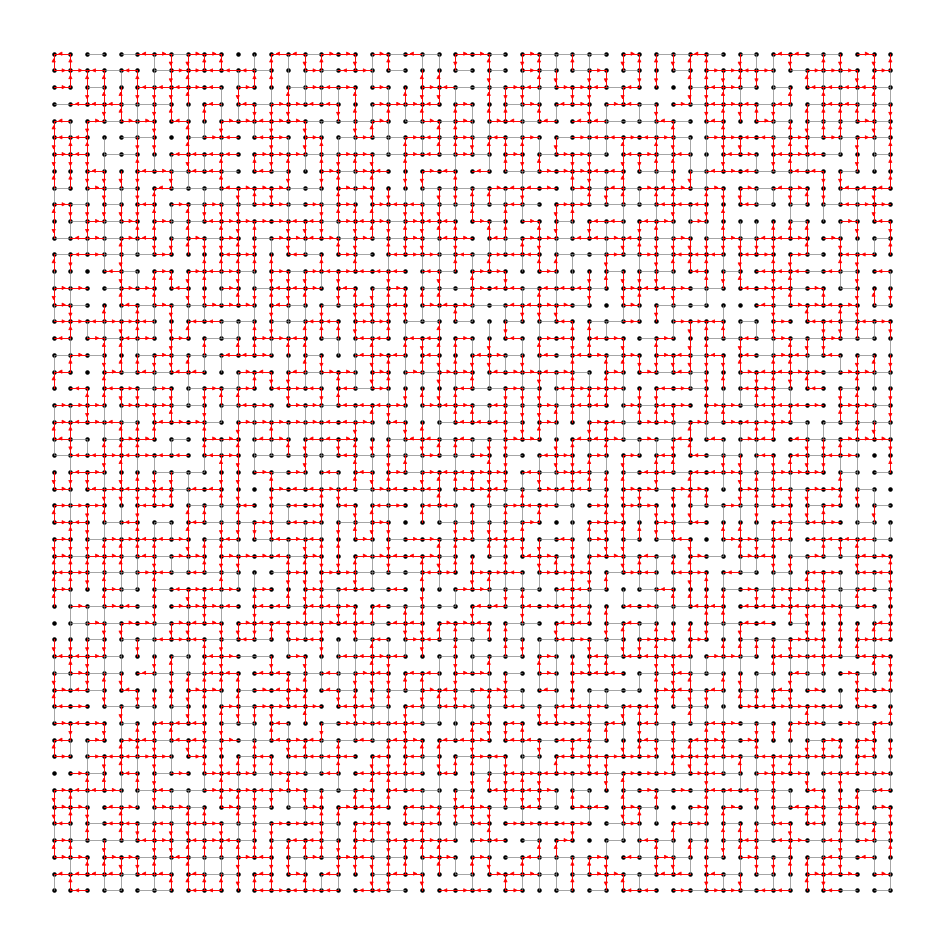

DiGraph with 777 nodes and 1176 edges
Found 777 components
Linking component 0: {2407}
	Checking node 2407...
	Node 2407 has neighbors [{2408: 156, 2458: 200, 2406: 392, 2356: 156}]
	Neighbor 2408 not in scc, linking 0 to 156:
	Added edge from 2407 to 2408
	Neighbor 2458 not in scc, linking 0 to 200:
	Added edge from 2407 to 2458
	Neighbor 2406 not in scc, linking 0 to 392:
	Added edge from 2407 to 2406
	Components 0 and 156 have already been connected this pass, skipping...
Connected component {2407}. New total component count is 773
Linking component 1: {713, 764}
	Checking node 764...
	Node 764 has neighbors [{763: 500, 713: 1, 815: 468}]
	Neighbor 763 not in scc, linking 1 to 500:
	Added edge from 764 to 763
	Added edge from 763 to 764
	Neighbor 713 belongs to component 1 too, skipping
	Neighbor 815 not in scc, linking 1 to 468:
	Added edge from 815 to 764
Connected component {713, 764}. New total component count is 771
Linking component 2: {2268, 2269}
	Checking node 2269...
	Node

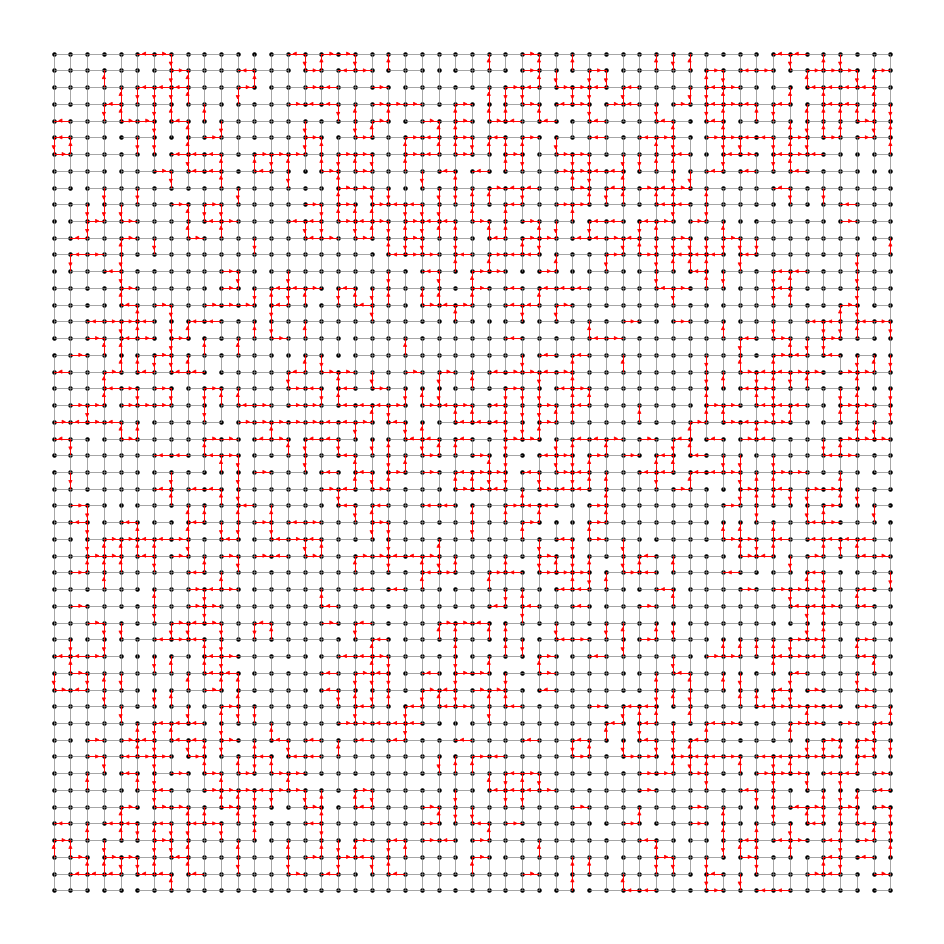

Loaded 2601 nodes and 7413 edges.
Data formatted for FleetPy use. Creating large_noisier subfolder in data/networks/...
Initial data saved to data\networks\large_noisier\base.
Running preprocessing and route completion steps...
	 ... creating adjacency matrix A ...
Running Floyd Warshall (travel time and distance of fastest route) in mp numba mode ...
	 ... loop 0/2601
	 ... loop 250/2601
	 ... loop 500/2601
	 ... loop 750/2601
	 ... loop 1000/2601
	 ... loop 1250/2601
	 ... loop 1500/2601
	 ... loop 1750/2601
	 ... loop 2000/2601
	 ... loop 2250/2601
	 ... loop 2500/2601
	 ... finished in 2.855 seconds
	 ... saving files to data\networks\large_noisier\ff\tables ...
reading data ...
checking connections ...
	...outgoing
	...incoming
		nodes to be connected: 0 without outgoing edges and 0 without incoming edges
connecting nodes that are connected via stop-only nodes ...
	added 0 edges that are connected via a stop-only node
taking care of remaining nodes to be connected: 0 without outgo

In [14]:
create_grid_data("large_noisier", 51, spacing=200, dropout=0.5)